In [456]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from matplotlib.ticker import FormatStrFormatter
from matplotlib.collections import LineCollection
import importlib
import scipy.linalg
sys.path.append('..')

# Now Python can see the 'src' folder!
import src.R2FMath as R2FMath
importlib.reload(R2FMath)

<module 'src.R2FMath' from 'c:\\python\\CeramicCap3\\analysis\\..\\src\\R2FMath.py'>

In [457]:
bd = r'U:\012 - CeramicCap\CAPDATA\2519J00896'
#fn ='VOLT_100nF-10nF_20260225_0848.dat'
#fn ='VOLT_1uF-100nF_20260225_1213.dat'
fn ='VOLT_10nF-1nF_20260224_1146.dat' 
#VOLT_10nF-1nF_20260202_1454.dat'
#bd = r'U:\012 - CeramicCap\CAPDATA\2519J00213'
#fn ='VOLT_10uF-1uF_20260225_1438.dat'
data = np.loadtxt(os.path.join(bd,fn))
ave = 0.5*(data[0:-1:2,:]+data[1::2,:])

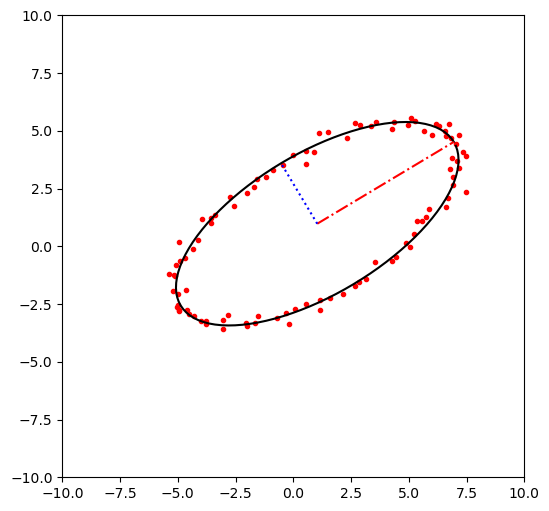

In [458]:
true_ellipse = R2FMath.ComplexEllipse(eta_o=1+1j, eta_ccw=5*np.exp(1j*30/180*np.pi), eta_cw=2*np.exp(1j*30/180*np.pi))

# Simulate what the R2F converter would actually see
x_noisy, y_noisy = true_ellipse.simulate_noisy_data(N=100, noise_std=0.2)

# Test your fitting algorithm
fitted_ellipse = R2FMath.ComplexEllipse.fit_from_points(x_noisy, y_noisy)
#fitted_cplx = fitted_ellipse.evaluate()

fig,ax = plt.subplots(1,figsize=(6,6))
ax.plot(x_noisy, y_noisy,'r.')

fitted_ellipse.plot_elli(ax)
#ax.plot(np.real(fitted_cplx), np.imag(fitted_cplx),'b-')
ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)
ax.set_aspect('equal')
#ax.set_aspect('equal', adjustable='box')
#plt.tight_layout()


39811.0


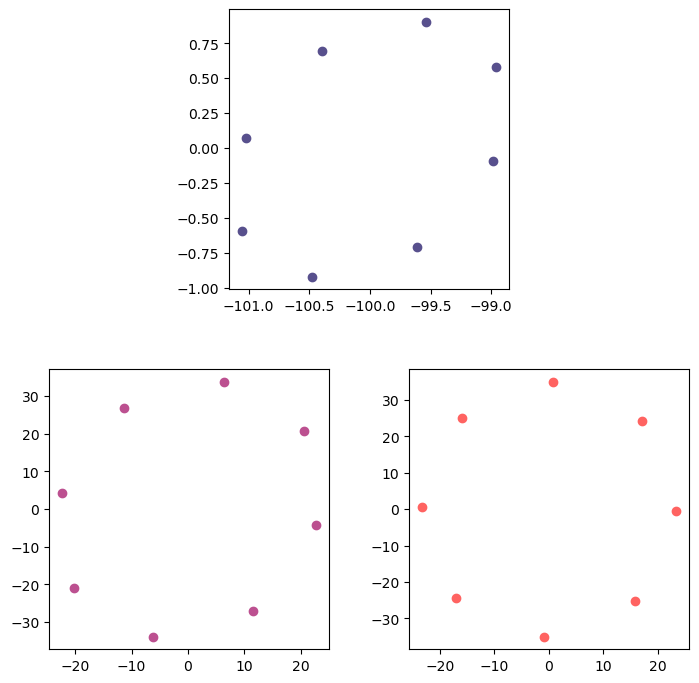

In [475]:

be =8*26
en = be+8
print(ave[be,0])
fig = plt.figure(figsize=(8, 8))
ax = []
w = 0.35  # Plot width
h = 0.35  # Plot height
dh = 0.1  # Vertical gap
dw = 0.1  # Horizontal gap
center_x = 0.5 - (w / 2)
ax.append(fig.add_axes((center_x, 0.1 + h + dh, w, h)))
ax.append(fig.add_axes((0.5 - w - dw/2, 0.1, w, h)))
ax.append(fig.add_axes((0.5 + dw/2, 0.1, w, h)))

#ax[0].plot(ave[be:en,4],ave[be:en,5],marker='o',c=co1,linestyle='None')
#ax[1].plot(ave[be:en,6],ave[be:en,7],marker='o',c=co2,linestyle='None')
#ax[2].plot(ave[be:en,8],ave[be:en,9],marker='o',c=co3,linestyle='None')
ax[0].plot(np.real(eta2),np.imag(eta2),marker='o',c=co1,linestyle='None')
ax[1].plot(np.real(eta3),np.imag(eta3),marker='o',c=co2,linestyle='None')
ax[2].plot(np.real(eta4),np.imag(eta4),marker='o',c=co3,linestyle='None')



eta2 =  1000*(ave[be:en,4]+1j*ave[be:en,5])/(ave[be:en,2]+1j*ave[be:en,3])
eta3 =  1000*(ave[be:en,6]+1j*ave[be:en,7])/(ave[be:en,2]+1j*ave[be:en,3])
eta4 =  1000*(ave[be:en,8]+1j*ave[be:en,9])/(ave[be:en,2]+1j*ave[be:en,3])

elli2 = fitted_ellipse = R2FMath.ComplexEllipse.fit_from_cmplx_points(eta2)
elli3 = fitted_ellipse = R2FMath.ComplexEllipse.fit_from_cmplx_points(eta3)
elli4 = fitted_ellipse = R2FMath.ComplexEllipse.fit_from_cmplx_points(eta4)

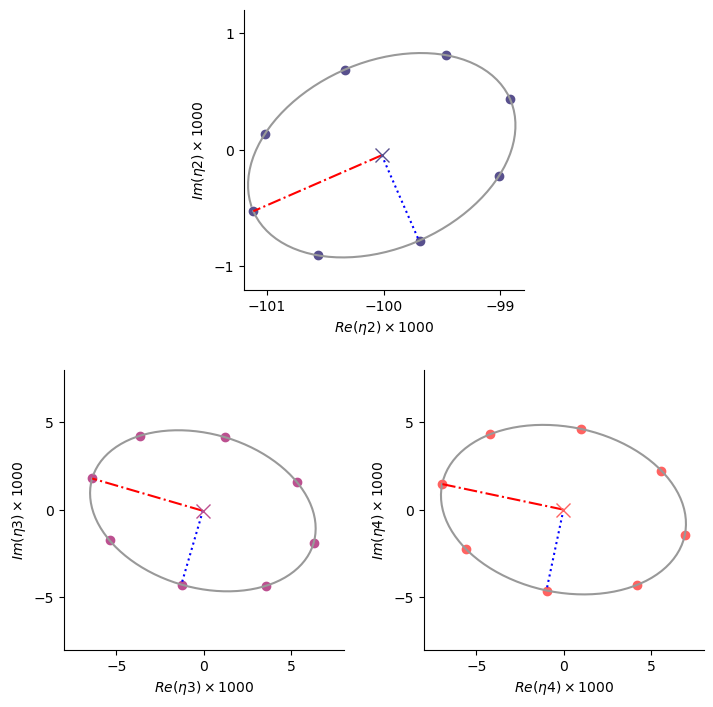

In [484]:
co1='#003f5c'
co2='#444e86'
co3='#955196'
co4='#dd5182'
co1='#58508d'
co2='#bc5090'
co3='#ff6361'
co4='#ffa600'
fig = plt.figure(figsize=(8, 8))
ax = []
w = 0.35  # Plot width
h = 0.35  # Plot height
dh = 0.1  # Vertical gap
dw = 0.1  # Horizontal gap
center_x = 0.5 - (w / 2)
ax.append(fig.add_axes((center_x, 0.1 + h + dh, w, h)))
ax.append(fig.add_axes((0.5 - w - dw/2, 0.1, w, h)))
ax.append(fig.add_axes((0.5 + dw/2, 0.1, w, h)))
ax[0].plot(np.real(eta2),np.imag(eta2),marker='o',c=co1,linestyle='None')
ax[1].plot(np.real(eta3),np.imag(eta3),marker='o',c=co2,linestyle='None')
ax[2].plot(np.real(eta4),np.imag(eta4),marker='o',c=co3,linestyle='None')
elli2.plot_elli(ax[0],ellipse_color='#999999')
elli3.plot_elli(ax[1],ellipse_color='#999999')
elli4.plot_elli(ax[2],ellipse_color='#999999')

ax[0].plot(np.real(elli2.eta_o),np.imag(elli2.eta_o),marker='x',ms=10,c=co1,linestyle='None')
ax[1].plot(np.real(elli3.eta_o),np.imag(elli3.eta_o),marker='x',ms=10,c=co2,linestyle='None')
ax[2].plot(np.real(elli4.eta_o),np.imag(elli4.eta_o),marker='x',ms=10,c=co3,linestyle='None')


ax[0].set_xlim(-101.2,-98.8)
ax[0].set_ylim(-1.2,1.2)
ax[1].set_xlim(-8,8)
ax[1].set_ylim(-8,8)

ax[2].set_xlim(-8,8)
ax[2].set_ylim(-8,8)

ax[0].set_xticks([-101,-100,-99])
ax[0].set_yticks([-1,0,1])
ax[1].set_yticks([-5,0,5])
ax[2].set_yticks([-5,0,5])

for n,axs in enumerate(ax):
    axs.spines['top'].set_visible(False)
    axs.spines['right'].set_visible(False)
    axs.set_xlabel(f'$Re(\eta{n+2})'+r'\times 1000$')
    axs.set_ylabel(f'$Im(\eta{n+2})'+r'\times 1000$')
    axs.ticklabel_format(useOffset=False)

fig.savefig('ellipses.pdf',bbox_inches='tight', 
               transparent=True,
               pad_inches=0)

In [464]:
gain3 = (elli3.eta_cw/elli2.eta_cw+elli3.eta_ccw/elli2.eta_ccw)/2
gain4 = (elli4.eta_cw/elli2.eta_cw+elli4.eta_ccw/elli2.eta_ccw)/2


(8.690777719033704e-05+3.436860049060948e-05j)
(7.444081883156706e-05+7.63910059690412e-05j)
(8.621008963327625e-05+3.462046646244487e-05j)


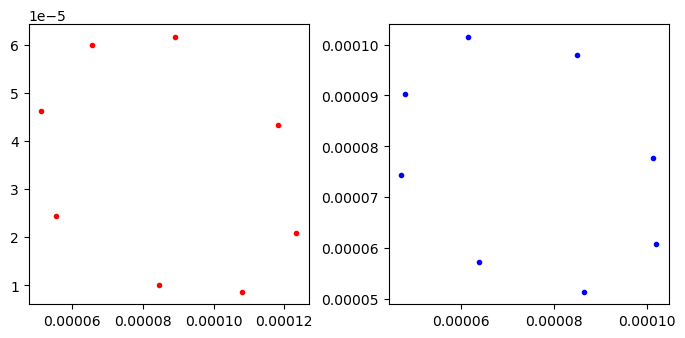

In [473]:
fig = plt.figure(figsize=(8, 8))
ax = []

w = 0.35  # Plot width
h = 0.35  # Plot height
dh = 0.1  # Vertical gap
dw = 0.1  # Horizontal gap

# Calculate the center for the top plot
# (0.5 - half the plot width) centers it exactly
center_x = 0.5 - (w / 2)

# 2. Bottom Left
ax.append(fig.add_axes((0.5 - w - dw/2, 0.1, w, h)))

# 3. Bottom Right

ax.append(fig.add_axes((0.5 + dw/2, 0.1, w, h)))
ax[0].plot(np.real(-eta2+eta3/gain3)/1000*10-1,np.imag(-eta2+eta3/gain3)/1000*10,'r.')
ax[1].plot(np.real(-eta2+eta4/gain4)/1000*10-1,np.imag(-eta2+eta4/gain4)/1000*10,'b.')
ax[0].ticklabel_format(useOffset=False)


print(np.mean(-eta2+eta3/gain3)/100-1)
print(np.mean(-eta2+eta4/gain4)/100-1)

print((-elli2.eta_o+ elli3.eta_o/gain3)/1000*10-1)

ratio3 = (-elli2.eta_o+ elli3.eta_o/gain3)/100-1



In [466]:
ratio3.imag

np.float64(0.00032604193853139985)

In [467]:
output=[]
for i in range(0, len(ave), 8):
    block = ave[i : i + 8,:]
    if len(block) < 8:
        print(f"Processing final partial block of size {len(block)}")
        break
    f = np.mean(block[:,0])
    eta2 =  1000*(block[:,4]+1j*block[:,5])/(block[:,2]+1j*block[:,3])
    eta3 =  1000*(block[:,6]+1j*block[:,7])/(block[:,2]+1j*block[:,3])
    eta4 =  1000*(block[:,8]+1j*block[:,9])/(block[:,2]+1j*block[:,3])

    elli2 = fitted_ellipse = R2FMath.ComplexEllipse.fit_from_cmplx_points(eta2)
    elli3 = fitted_ellipse = R2FMath.ComplexEllipse.fit_from_cmplx_points(eta3)
    elli4 = fitted_ellipse = R2FMath.ComplexEllipse.fit_from_cmplx_points(eta4)    
    #gain3 = (elli3.eta_cw/elli2.eta_cw+elli3.eta_ccw/elli2.eta_ccw)/2
    #gain4 = (elli4.eta_cw/elli2.eta_cw+elli4.eta_ccw/elli2.eta_ccw)/2
    
    
    gain3 = elli3.eta_cw/elli2.eta_cw
    gain4 = elli4.eta_cw/elli2.eta_cw
    
    ratio3 = (-elli2.eta_o+ elli3.eta_o/gain3)/100-1
    ratio4 = (-elli2.eta_o+ elli4.eta_o/gain4)/100-1

    alpha3 = ratio3.real
    beta3  = ratio3.imag
    alpha4 = ratio4.real
    beta4  = ratio4.imag
    #alpha3 = np.mean(np.real(-eta2+eta3/gain3)/1000*10-1)
    #beta3  = np.mean(np.imag(-eta2+eta3/gain3)/1000*10)
    #alpha4 = np.mean(np.real(-eta2+eta4/gain4)/1000*10-1)
    #beta4  = np.mean(np.imag(-eta2+eta4/gain4)/1000*10)
    line = np.hstack((f, np.abs(gain3), np.abs(gain4), np.angle(gain3), np.angle(gain4), alpha3,beta3, alpha4,beta4))
    output.append(line)
output= np.array(output)


def average_output(output):
    mydict = {}
    for line in output:
        f = line[0]
        if  f not in mydict:
            mydict[f] = np.array(line)
        else:
            mydict[f] = np.vstack((mydict[f] ,np.array(line)))
    means =[]
    stds =[]
    for f in list(mydict):
        if len(np.shape(mydict[f][1]))==1:
            means.append(np.mean(mydict[f],axis=0))
            stds.append(np.std(mydict[f],axis=0,ddof=1))
        else:
            means.append(np.array(mydict[f]))
            stds.append(np.zeros_like(mydict[f]))
    means = np.array(means)
    stds = np.array(stds)

    return means,stds                      



In [468]:
myd,me=average_output(output)

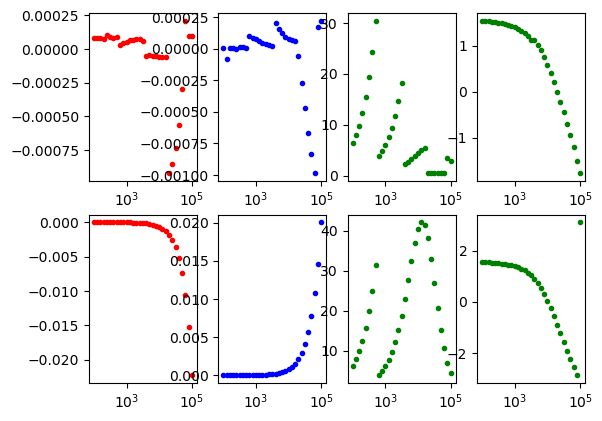

In [469]:
fig,ax = plt.subplots(2,4)
ax = ax.flatten()
ax[0].plot(md[:,0],md[:,5],'r.')   #alpha3
ax[1].plot(md[:,0],md[:,6],'b.')   #beta3
ax[2].plot(md[:,0],md[:,1],'g.')   #gain3=abs
ax[3].plot(md[:,0],md[:,3],'g.')   #gain3-angle
ax[4].plot(md[:,0],md[:,7],'r.')   #alpha4
ax[5].plot(md[:,0],md[:,8],'b.')   #beta4
ax[6].plot(md[:,0],md[:,2],'g.')   #gain4
ax[7].plot(md[:,0],md[:,4],'g.')   #gain4

for a in ax:
    a.set_xscale('log')

In [470]:
data_ana =  np.loadtxt(os.path.join(bd,'CC3_10nF-1nF_20260224_1146.dat'))

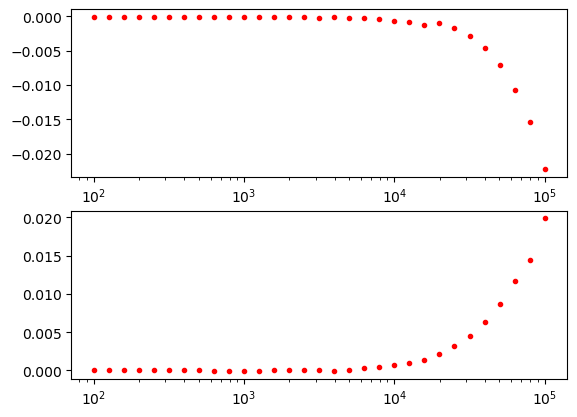

In [471]:
fig,ax = plt.subplots(2)
ax = ax.flatten()
ax[0].errorbar(md[:,0],md[:,7]-md[:,5],np.sqrt(sd[:,7]**2+sd[:,5]**2),fmt='r.')
ax[1].errorbar(md[:,0],md[:,8]-md[:,6],np.sqrt(sd[:,8]**2+sd[:,6]**2),fmt='r.')
#ax[0].plot(data_ana[:,0],data_ana[:,3]-data_ana[:,2],'b.')
#ax[1].plot(data_ana[:,0],data_ana[:,5]-data_ana[:,4],'b.')
#ax[0].set_xlim(100,10000)
#ax[0].set_ylim(-1e-3,1e-3)

ax[0].set_xscale('log')
ax[1].set_xscale('log')



In [ ]:
np.sqrt(sd[:,5]**2+sd[:,3]**2)

array([1.11897728e-02, 1.81111377e+00, 8.48143913e-04, 4.31223065e-04,
       2.08153868e-03, 1.00767050e-03, 1.20121204e-04, 3.64046251e-04,
       1.17108006e-04, 2.41070509e-04, 1.78975127e-04, 1.71874266e-04,
       3.43195825e-04, 2.45661139e-04, 1.83920749e-04, 2.14253838e-04,
       3.00813270e-04, 1.13822527e-04, 2.62575386e-04, 1.70693321e-04,
       2.76868604e-04, 3.06779387e-04, 1.62837249e-04, 9.66915269e-05,
       1.08096787e-04, 3.24955958e-04, 1.10172465e-04, 5.90956800e-05,
       1.97430359e-04, 1.45557824e-05, 4.22501693e-05])

In [ ]:
sd

[array([0.00000000e+00, 3.14969859e-02, 1.59596246e-03, 2.44938079e-05,
        2.17797487e-05, 4.06058948e-06, 1.31811036e-06]),
 array([0.00000000e+00, 2.31425861e-01, 7.62135698e-03, 1.50488586e-04,
        8.05104591e-05, 4.98410391e-06, 2.58513470e-06]),
 array([0.00000000e+00, 3.72340757e-03, 2.81532989e-03, 4.37935454e-06,
        2.75354157e-06, 4.10969577e-06, 1.05294647e-06]),
 array([0.00000000e+00, 3.60072666e-03, 2.99139529e-03, 3.39459227e-06,
        1.59123313e-06, 3.58058855e-06, 1.25942704e-06]),
 array([0.00000000e+00, 3.31271276e-02, 4.07061515e-03, 1.34298772e-05,
        1.02012337e-05, 4.22321219e-06, 8.40872734e-07]),
 array([0.00000000e+00, 2.26760124e-02, 4.67200774e-03, 6.63407239e-06,
        3.07810047e-06, 3.77030833e-06, 9.19728144e-07]),
 array([0.00000000e+00, 9.73155570e-03, 4.64868412e-03, 4.03028955e-06,
        1.55602951e-06, 4.71945659e-06, 6.58602407e-07]),
 array([0.00000000e+00, 7.20393312e-03, 6.31377681e-03, 2.06199921e-06,
        9.89516199